### Hybrid Search using Langchain and Pinecone

In [1]:
## Install the pinecone library
import sys
!"{sys.executable}" -m pip install pinecone

In [9]:
!"{sys.executable}" -m pip install --upgrade pip setuptools wheel

  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
Using cached wheel-0.47.0-py3-none-any.whl (32 kB)

   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
   ---------------------------------------- 0/2 [wheel]
  Attempting uninstall: setuptools
   ---------------------------------------- 0/2 [wheel]
    Found existing installation: setuptools 81.0.0
   ---------------------------------------- 0/2 [wheel]
   -------------------- ------------------- 1/2 [setuptools]
   -------------------- ------------------- 1/2 [setuptools]
    Uninstalling setuptools-81.0.0:
   -------------------- ------------------- 1/2 [setuptools]
   -------------------- ------------------- 1/2 [setuptools]
   -------------------- ------------------- 1/2 [setuptool

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.12.0 requires setuptools<82, but you have setuptools 82.0.1 which is incompatible.


In [12]:
## Install other pinecone libraries
!"{sys.executable}" -m pip install pinecone-text pinecone-notebooks pinecone-client

  Using cached pinecone_text-0.11.0-py3-none-any.whl.metadata (10 kB)
  Using cached pinecone_notebooks-0.1.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached pinecone_client-6.0.0-py3-none-any.whl.metadata (3.4 kB)
  Using cached mmh3-4.1.0.tar.gz (26 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached nltk-3.9.4-py3-none-any.whl.metadata (3.2 kB)
  Using cached pinecone_plugin_interface-0.0.7-py3-none-any.whl.metadata (1.2 kB)
Using cached pinecone_text-0.11.0-py3-none-any.whl (22 kB)
Using cached nltk-3.9.4-py3-none-any.whl (1.6 MB)
Using cached pinecone_notebooks-0.1.1-py3-none-any.whl (7.3 kB)
Using cached pinecone_client-6.0.0-py3-none-any.whl (6.7 kB)
Using cached pinecone_plugin_interf

  error: subprocess-exited-with-error
  
  × Building wheel for mmh3 (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [64 lines of output]
      C:\Users\dhruv\AppData\Local\Temp\pip-build-env-fpn61ehd\overlay\Lib\site-packages\setuptools\config\_apply_pyprojecttoml.py:82: SetuptoolsDeprecationWarning: `project.license` as a TOML table is deprecated
      !!
      
              ********************************************************************************
              Please use a simple string containing a SPDX expression for `project.license`. You can also use `project.license-files`. (Both options available on setuptools>=77.0.0).
      
              By 2027-Feb-18, you need to update your project and remove deprecated calls
              or your builds will no longer be supported.
      
              See https://packaging.python.org/en/latest/guides/writing-pyproject-toml/#license for details.
              ****************************************************

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

## Get the pinecone api key
pinecone_api_key = os.getenv('PINECONE_API_KEY')

In [4]:
from langchain_community.retrievers import PineconeHybridSearchRetriever
from pinecone import Pinecone, ServerlessSpec

index_name = "hybrid-search-langchain-pinecone"

## initialize the Pinecone client
pc = Pinecone(api_key = pinecone_api_key)

## create the index
if index_name not in pc.list_indexes().names():
    pc.create_index(
        name = index_name,
        
        ## dimensionality of dense model
        dimension = 384,  

        ## sparse values supported only for dotproduct
        metric = "dotproduct",  
        spec = ServerlessSpec(cloud = "aws", region = "us-east-1"),
    )

In [ ]:
## Get the index with the database
index = pc.Index(index_name)
index

Index(host='https://hybrid-search-langchain-pinecone-t3ecvok.svc.aped-4627-b74a.pinecone.io')

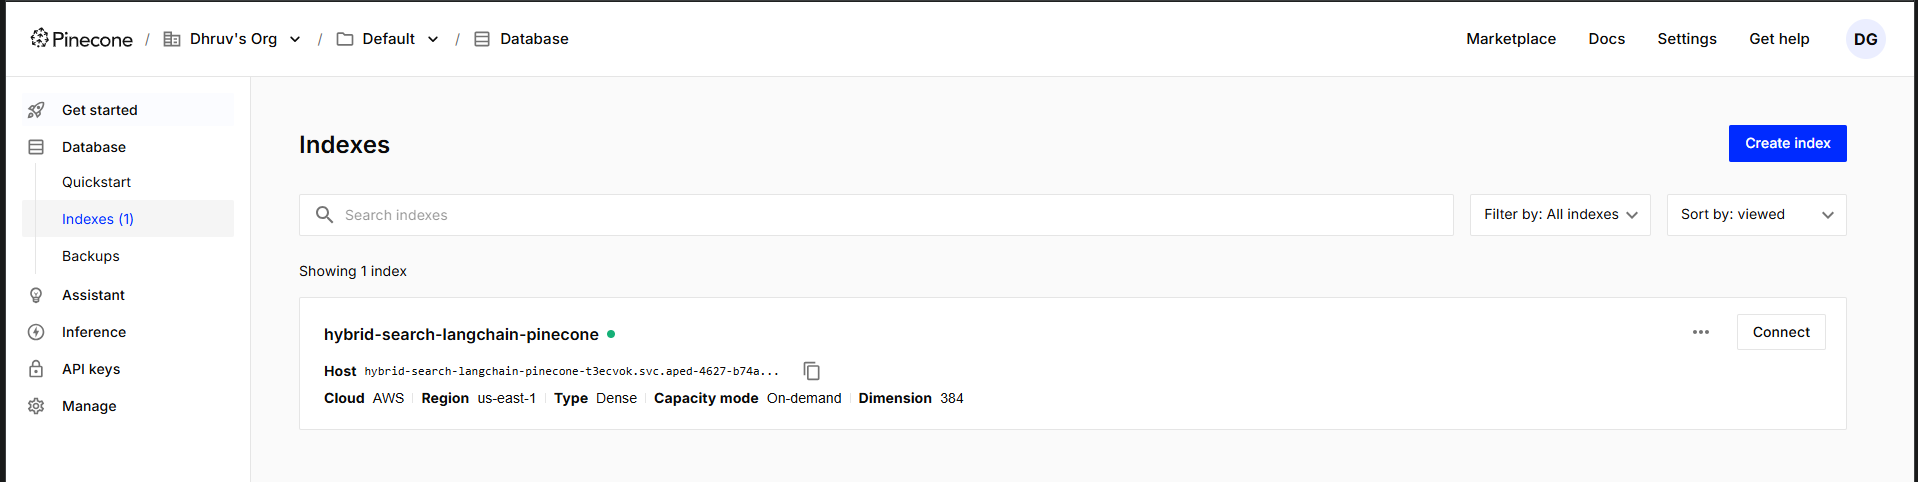

In [6]:
## vector embedding and sparse matrix
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name = "all-MiniLM-L6-v2")
embeddings

d:\Udemy Material\Langchain-V2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4928.34it/s]


HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [ ]:
## Conversion of sparse matrix
from pinecone_text.sparse import BM25Encoder

bm25_encoder = BM25Encoder().default()
bm25_encoder

In [ ]:
sentences = [
    "In 2023, I visited Paris",
    "In 2022, I visited New York",
    "In 2021, I visited New Orleans",
]

## tfidf values on these sentence
bm25_encoder.fit(sentences)

## store the values to a json file
bm25_encoder.dump("bm25_values.json")

## load to your BM25Encoder object
bm25_encoder = BM25Encoder().load("bm25_values.json")

100%|██████████| 3/3 [00:00<00:00, 2995.93it/s]


In [ ]:
## Get the pinecone retriever
retriever = PineconeHybridSearchRetriever(
    embeddings = embeddings,
    sparse_encoder = bm25_encoder,
    index = index
)

In [ ]:
retriever

PineconeHybridSearchRetriever(embeddings=HuggingFaceEmbeddings(client=SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
), model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, multi_process=False, show_progress=False), sparse_encoder=<pinecone_text.sparse.bm25_encoder.BM25Encoder object at 0x0000020F55236530>, index=<pinecone.data.index.Index object at 0x0000020F5D2F4730>)

In [ ]:
## Add texts into the database index
retriever.add_texts(
    [
        "In 2023, I visited Paris",
        "In 2022, I visited New York",
        "In 2021, I visited New Orleans",
    ]
)

100%|██████████| 1/1 [00:04<00:00,  4.54s/it]


In [ ]:
## Invoke the retriever
retriever.invoke("What city did i visit first")

[Document(page_content='In 2021, I visited New Orleans'),
 Document(page_content='In 2022, I visited New York'),
 Document(page_content='In 2023, I visited Paris')]